# Analysis of Amino Acid Distribution in CDR Regions of Different Antibody Groups

## Analysis of Amino Acid Distribution
This Jupyter Notebook analyzes the **amino acid distributions in the complementarity-determining regions (CDR-H1, CDR-H2, CDR-H3)** of antibodies targeting different antigens (SARS-CoV-2, Influenza, and human-specific targets). The goal is to identify potentially characteristic differences between these groups.

### Approach
1. **Calculation of amino acid distributions:**
   - For each CDR region, the relative frequency of each amino acid was calculated.
   - This was done separately for each antigen source: `Corona`, `Influenza`, and `Human`.

2. **Visualization:**
   - Grouped bar plots display the amino acid distributions per region and antigen group.

3. **Statistical significance analysis:**

   - The **Mann–Whitney U test** was used to compare distributions between groups.
   - combined dataframe mit all the results from `Mann-Whitney U` test was made
   - p-values were adjusted using the **Benjamini–Hochberg correction**.
   - Results were visualized as a heatmap using `-log10(adjusted p-value)`.
   - In the heatmap, differences with **–log₁₀(adjusted p) > 1.3** are considered statistically significant, as this corresponds to an **adjusted p-value < 

## Analysis of Amino Acid Property Groups

In addition to analyzing the distribution of individual amino acids, the residues were grouped into five chemically and functionally relevant categories:

- **Nonpolar (hydrophobic)**: A, V, L, I, M, P, G  
- **Polar (hydrophilic)**: S, T, N, Q, C  
- **Basic**: K, R, H  
- **Acidic**: D, E  
- **Aromatic**: F, W, Y
For each CDR region and antigen group (`Corona`, `Influenza`, `Human`), the **summed relative frequency** of each property group was calculated.

### Visualization:
- Grouped bar plots were used to compare the distribution of amino acid property classes across antibody groups.

## Calculation of amino acid distributions:

In [4]:
import pandas as pd

# Datensets laden (vorher in data cleanup Ordner erstellt)
df_corona = pd.read_csv("../../generated/cdrs/seq/corona_cdr_seq.tsv", sep="\t")
df_human = pd.read_csv("../../generated/cdrs/seq/human_cdr_seq.tsv", sep="\t")
df_influenza = pd.read_csv("../../generated/cdrs/seq/influenza_cdr_seq.tsv", sep="\t")



In [5]:
# Mapping von 1-Buchstaben zu 3-Buchstaben Aminosäuren
aa_1_to_3 = {
    'A': 'Ala', 'R': 'Arg', 'N': 'Asn', 'D': 'Asp', 'C': 'Cys',
    'Q': 'Gln', 'E': 'Glu', 'G': 'Gly', 'H': 'His', 'I': 'Ile',
    'L': 'Leu', 'K': 'Lys', 'M': 'Met', 'F': 'Phe', 'P': 'Pro',
    'S': 'Ser', 'T': 'Thr', 'W': 'Trp', 'Y': 'Tyr', 'V': 'Val'
} 

# Berechnen wie oft eine Aminosäure in der jeweiligen CDRs vorkommt (in Prozent)
def calculate_aa_distribution(df, column):
    aa_counts = df[column].dropna().apply(lambda x: pd.Series(list(x))).stack().value_counts() # wie oft jede AS vorkommt
    total_count = aa_counts.sum() # Totale Anzahl der Aminosäuren in der jeweiligen CDR-Region
    aa_distribution = (aa_counts / total_count * 100).round(2) # konvertiere in Prozent und runde auf 2 Dezimalstellen
    return aa_distribution 


import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_aa_distribution(corona, influenza, human, region_label="CDR_H3"): #definition der Funktion um die Verteilung der Aminosäuren zu plotten
    """
    Plots the grouped amino acid distribution for three datasets.
    Args:
        corona (pd.Series): Amino acid distribution for Corona.
        influenza (pd.Series): Amino acid distribution for Influenza.
        human (pd.Series): Amino acid distribution for Human.
        region_label (str): Label for the region being analyzed.
    """

    aa_order = list(aa_1_to_3.keys()) # aa_order ist eine Liste der Aminosäuren in der Reihenfolge von aa_1_to_3
    labels_3 = [aa_1_to_3[aa] for aa in aa_order] # labels_3 ist eine Liste der Aminosäuren in der 3-Buchstaben Abkürzung

    # Reindexiere die Verteilung der Aminosäuren, um sicherzustellen, dass alle Aminosäuren in der gleichen Reihenfolge sind
    corona = corona.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Corona
    influenza = influenza.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Influenza
    human = human.reindex(aa_order, fill_value=0) # Reindexiere die Verteilung der Aminosäuren für Human

    x = np.arange(len(aa_order)) # Positionen der Balken auf der x-Achse
    width = 0.25 # Breite der Balken

    # Generieren  des Balkendiagramms
    plt.figure(figsize=(12, 6)) # Größe des Diagramms
    # Balken, Position, Label und Farbe
    plt.bar(x - width, corona.values, width, label='Corona', color="#B3E3F4") 
    plt.bar(x,         influenza.values, width, label='Influenza', color='#0BBCC5') 
    plt.bar(x + width, human.values, width, label='Human', color='#132740') 

    plt.xticks(ticks=x, labels=labels_3, rotation=45)
    plt.ylabel("Häufigkeit (%)")
    plt.xlabel("Aminosäure")
    plt.title(f"Aminosäureverteilung in {region_label}")
    plt.ylim(0, 25)  
    plt.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


## Visualization of the Amino Acid distribution

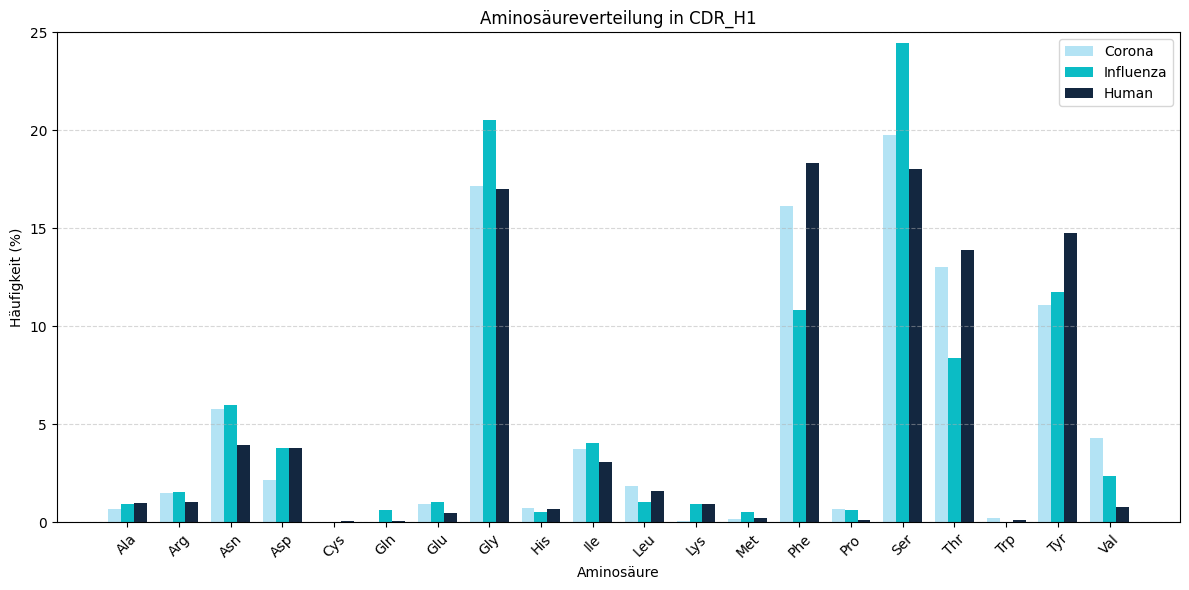

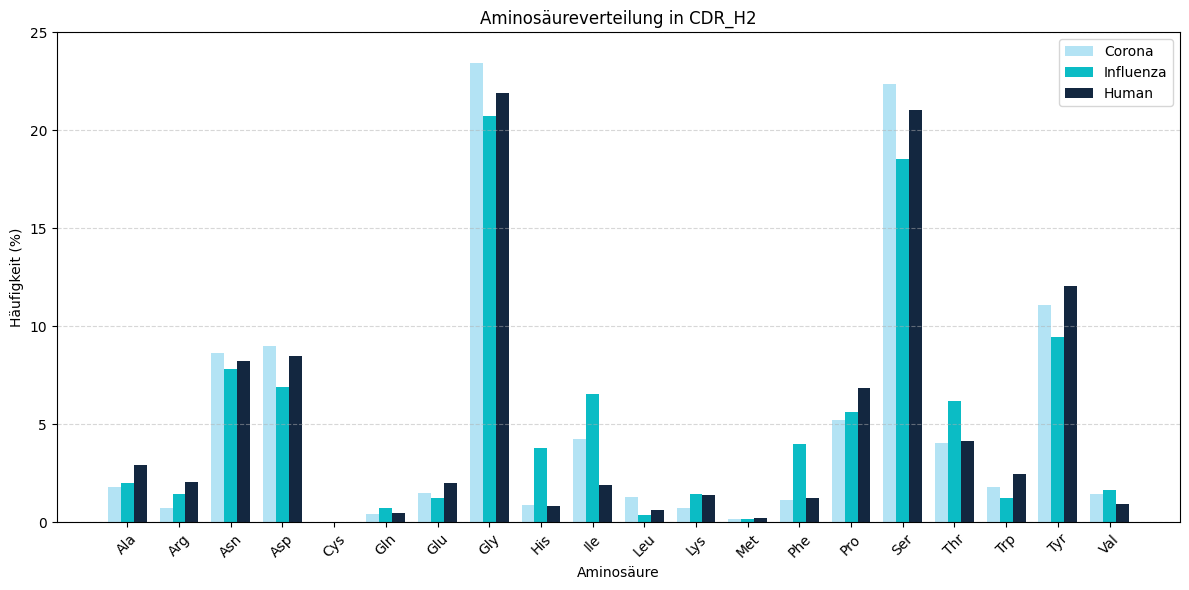

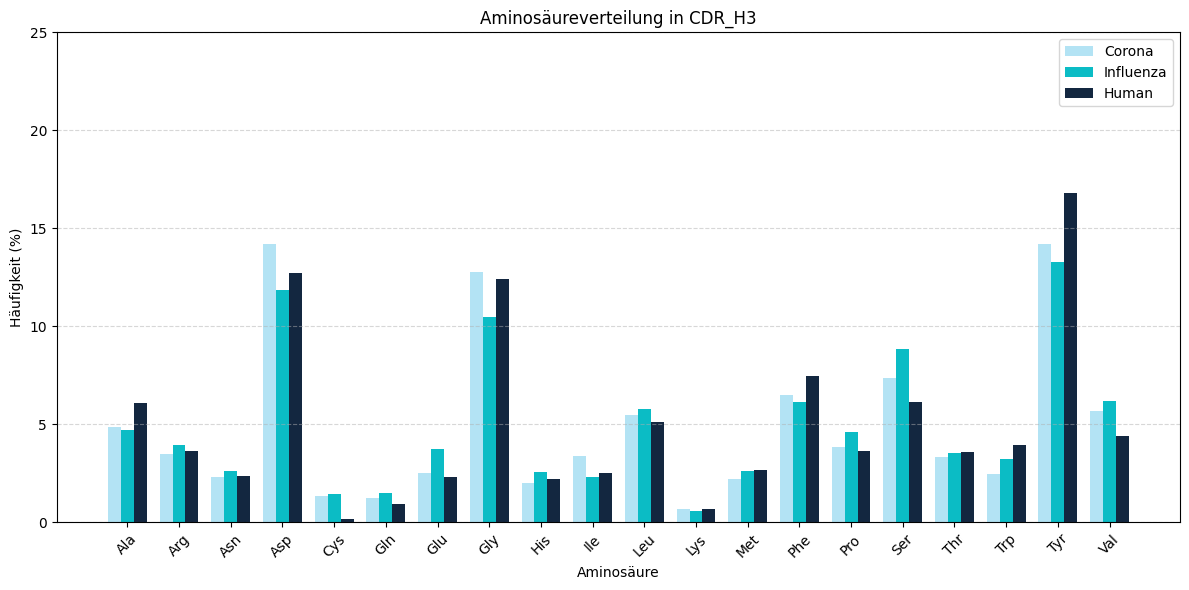

In [6]:
for region in ["CDR_H1", "CDR_H2", "CDR_H3"]: # für jede Region in der Liste "region" wird die Funktion plot_grouped_aa_distribution aufgerufen
    plot_grouped_aa_distribution(
        calculate_aa_distribution(df_corona, region), # Berechnung der Aminosäureverteilung für Corona
        calculate_aa_distribution(df_influenza, region), # Berechnung der Aminosäureverteilung für Influenza
        calculate_aa_distribution(df_human, region), # Berechnung der Aminosäureverteilung für Human
        region_label=region
    )


## Statistical significance analysis- Mann-Withney-U-Test

In [7]:
def compute_aa_frequencies(df, colname, group_label): #berechnet die relative Häufigkeit der Aminosäuren in der angegebenen Spalte
    def rel_freq(seq):
        counts = pd.Series(list(seq)).value_counts() #zähle wie oft jede Aminosäure vorkommt
        total = len(seq) #berechne die Gesamtlänge der Sequenz
        return counts / total if total > 0 else pd.Series(dtype=float) #rückgabe der relativen Häufigkeit der Aminosäuren, wenn die Gesamtlänge größer als 0 ist, sonst eine leere Serie

    aa_df = df[colname].dropna().apply(rel_freq).fillna(0) #spalte colname wird auf NaN-Werte überprüft und die relative Häufigkeit der Aminosäuren wird berechnet
    aa_df["group"] = group_label # füge eine neue Spalte "group" hinzu, die den Gruppennamen enthält
    return aa_df

corona_aa = compute_aa_frequencies(df_corona, "CDR_H3", "Corona") 
influenza_aa = compute_aa_frequencies(df_influenza, "CDR_H3", "Influenza")
human_aa = compute_aa_frequencies(df_human, "CDR_H3", "Human")

all_aa = pd.concat([corona_aa, influenza_aa, human_aa], ignore_index=True).fillna(0) # Kombiniere alle Aminosäureverteilungen in einem DataFrame

all_aa

,F,T,D,Y,G,N,E,W,L,P,...,I,H,S,A,V,Q,M,C,K,group
0,0.250000,0.187500,0.187500,0.125000,0.062500,0.062500,0.062500,0.062500,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,Corona
1,0.000000,0.000000,0.111111,0.111111,0.111111,0.000000,0.111111,0.000000,0.222222,0.111111,...,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,Corona
2,0.047619,0.047619,0.142857,0.095238,0.190476,0.095238,0.000000,0.095238,0.047619,0.047619,...,0.000000,0.047619,0.047619,0.047619,0.047619,0.000000,0.000000,0.0,0.0,Corona
3,0.000000,0.000000,0.052632,0.263158,0.157895,0.000000,0.000000,0.000000,0.000000,0.052632,...,0.000000,0.052632,0.000000,0.157895,0.105263,0.105263,0.052632,0.0,0.0,Corona
4,0.000000,0.000000,0.166667,0.083333,0.250000,0.000000,0.000000,0.083333,0.250000,0.000000,...,0.083333,0.000000,0.000000,0.000000,0.000000,0.083333,0.000000,0.0,0.0,Corona
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.083333,0.000000,0.083333,0.166667,0.250000,0.000000,0.000000,0.083333,0.083333,0.000000,...,0.083333,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.0,0.0,Human
957,0.076923,0.000000,0.153846,0.153846,0.153846,0.000000,0.000000,0.076923,0.076923,0.076923,...,0.000000,0.000000,0.230769,0.000000,0.000000,0.000000,0.000000,0.0,0.0,Human
958,0.058824,0.000000,0.058824,0.235294,0.117647,0.058824,0.000000,0.000000,0.058824,0.000000,...,0.058824,0.000000,0.058824,0.058824,0.176471,0.000000,0.058824,0.0,0.0,Human
959,0.272727,0.000000,0.090909,0.181818,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,...,0.000000,0.000000,0.000000,0.090909,0.090909,0.000000,0.090909,0.0,0.0,Human


In [8]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def mann_whitney_comparison(df1, df2, aa_list, label1="Group1", label2="Group2"):
    results = []
    for aa in aa_list:
        group1 = df1[aa] if aa in df1 else pd.Series([0]*len(df1))
        group2 = df2[aa] if aa in df2 else pd.Series([0]*len(df2))
        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
        results.append((aa, aa_1_to_3[aa], group1.mean(), group2.mean(), p))
    df_result = pd.DataFrame(results, columns=["AA", "AA_3", f"Mean_{label1}", f"Mean_{label2}", "p_value"])
    df_result["adjusted_p"] = multipletests(df_result["p_value"], method="fdr_bh")[1]
    return df_result.sort_values("adjusted_p")


In [9]:
all_results = {}

for region in ["CDR_H1", "CDR_H2", "CDR_H3"]:
    print(f" Vergleich für {region}...")

    # Frequenzen berechnen
    corona = compute_aa_frequencies(df_corona, region, "Corona")
    influenza = compute_aa_frequencies(df_influenza, region, "Influenza")
    human = compute_aa_frequencies(df_human, region, "Human")

    aa_list = list(aa_1_to_3.keys())

    # Paarvergleiche
    result_ci = mann_whitney_comparison(corona, influenza, aa_list, "Corona", "Influenza")
    result_ch = mann_whitney_comparison(corona, human, aa_list, "Corona", "Human")
    result_ih = mann_whitney_comparison(influenza, human, aa_list, "Influenza", "Human")

    # Speichern
    all_results[f"{region}_Corona_vs_Influenza"] = result_ci
    all_results[f"{region}_Corona_vs_Human"] = result_ch
    all_results[f"{region}_Influenza_vs_Human"] = result_ih

for name, df in all_results.items():
    print(f"\n🔎 {name}")
    print(df[["AA_3", f"Mean_{name.split('_vs_')[0].split('_')[-1]}", f"Mean_{name.split('_vs_')[-1]}", "adjusted_p"]].head(5))



 Vergleich für CDR_H1...
 Vergleich für CDR_H2...
 Vergleich für CDR_H3...

🔎 CDR_H1_Corona_vs_Influenza
   AA_3  Mean_Corona  Mean_Influenza    adjusted_p
16  Thr     0.131762        0.087038  6.562774e-07
5   Gln     0.000306        0.007106  1.223146e-04
11  Lys     0.000782        0.009799  1.223146e-04
13  Phe     0.163576        0.116537  1.890593e-04
3   Asp     0.021333        0.038387  2.271734e-03

🔎 CDR_H1_Corona_vs_Human
   AA_3  Mean_Corona  Mean_Human    adjusted_p
19  Val     0.042591    0.006929  4.887399e-18
18  Tyr     0.112560    0.148835  4.962466e-07
11  Lys     0.000782    0.009380  2.859216e-06
3   Asp     0.021333    0.038114  1.783531e-04
2   Asn     0.058113    0.039968  4.966919e-04

🔎 CDR_H1_Influenza_vs_Human
   AA_3  Mean_Influenza  Mean_Human    adjusted_p
13  Phe        0.116537    0.186999  3.425366e-08
16  Thr        0.087038    0.141013  7.390141e-08
7   Gly        0.203373    0.168541  4.802843e-04
15  Ser        0.235564    0.176392  2.245945e-03
5 

In [10]:
all_dfs = []  # Liste zum Speichern aller DataFrames für die finale Zusammenführung
for name, df in all_results.items(): # Durchlaufe alle Ergebnisse
    region, comparison = name.split("_", 1) # Teile den Namen in Region und Vergleich
    df = df.copy() # Erstelle eine Kopie des DataFrames, um Änderungen vorzunehmen
    df["region"] = region # Füge die Region als neue Spalte hinzu
    df["comparison"] = comparison # Füge den Vergleich als neue Spalte hinzu
    all_dfs.append(df) # Füge den DataFrame der Liste hinzu

# Kombiniere alle DataFrames in der Liste zu einem einzigen DataFrame
df_combined = pd.concat(all_dfs, ignore_index=True) #
df_combined = df_combined[["region", "comparison", "AA_3", "Mean_Corona", "Mean_Influenza", "Mean_Human", "p_value", "adjusted_p"]] #df_combined wird auf die gewünschten Spalten reduziert

df_combined

,region,comparison,AA_3,Mean_Corona,Mean_Influenza,Mean_Human,p_value,adjusted_p
0,CDR,H1_Corona_vs_Influenza,Thr,0.131762,0.087038,NaN,3.281387e-08,6.562774e-07
1,CDR,H1_Corona_vs_Influenza,Gln,0.000306,0.007106,NaN,1.834720e-05,1.223146e-04
2,CDR,H1_Corona_vs_Influenza,Lys,0.000782,0.009799,NaN,1.511197e-05,1.223146e-04
3,CDR,H1_Corona_vs_Influenza,Phe,0.163576,0.116537,NaN,3.781186e-05,1.890593e-04
4,CDR,H1_Corona_vs_Influenza,Asp,0.021333,0.038387,NaN,5.679334e-04,2.271734e-03
...,...,...,...,...,...,...,...,...
175,CDR,H3_Influenza_vs_Human,Thr,NaN,0.037451,0.037362,2.876419e-01,3.595523e-01
176,CDR,H3_Influenza_vs_Human,Met,NaN,0.025426,0.026186,6.369474e-01,7.193099e-01
177,CDR,H3_Influenza_vs_Human,Trp,NaN,0.032151,0.040915,6.473789e-01,7.193099e-01
178,CDR,H3_Influenza_vs_Human,Ile,NaN,0.025172,0.025487,6.855382e-01,7.216192e-01


## Visualization of Mann-Whitney-U-Test (Heatmap)

In [11]:
# Leeres Dictionary für Heatmap-Daten
heatmap_data = {}

# Schleife über alle gespeicherten Ergebnisse
for name, df in all_results.items():
    row_label = name.replace("_", ": ").replace("CDR", "CDR-")  # schöner formatieren
    row = {aa_1_to_3[aa]: -np.log10(p) if p > 0 else 10 for aa, p in zip(df["AA"], df["adjusted_p"])}
    heatmap_data[row_label] = row

import pandas as pd
import numpy as np

df_heatmap = pd.DataFrame.from_dict(heatmap_data, orient="index").fillna(0)



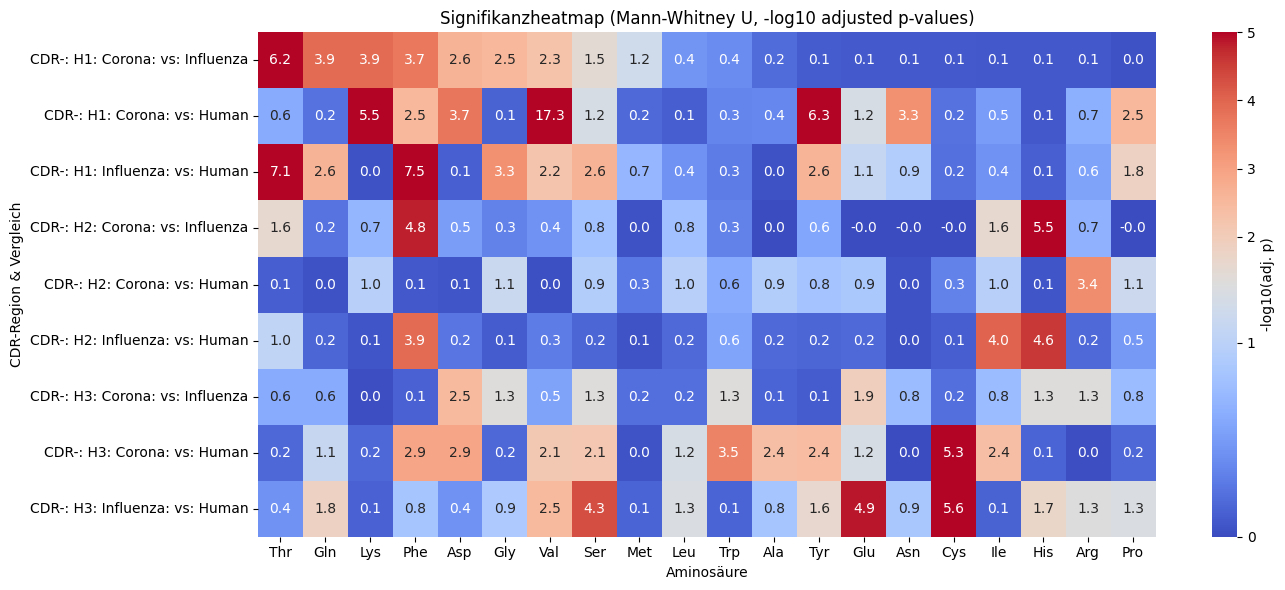

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Normierung der Farbskala: Mitte = 1.3
norm = TwoSlopeNorm(vmin=0, vcenter=1.3, vmax=5)

plt.figure(figsize=(14, 6))
sns.heatmap(
    df_heatmap,
    cmap="coolwarm",          # blau–weiß–rot-Verlauf
    annot=True,
    fmt=".1f",
    cbar_kws={'label': '-log10(adj. p)'},
    norm=norm                 # kritischer Punkt bei 1.3
)

plt.title("Signifikanzheatmap (Mann-Whitney U, -log10 adjusted p-values)")
plt.xlabel("Aminosäure")
plt.ylabel("CDR-Region & Vergleich")
plt.tight_layout()
plt.show()


## Analysis of Amino Acid Composition by groups

In [16]:
# Berechne die Aminosäurefrequenzen für jede Gruppe und Region
aac_sars_h3 = compute_aa_frequencies(df_corona, "CDR_H3", "Corona")
aac_influenza_h3 = compute_aa_frequencies(df_influenza, "CDR_H3", "Influenza")
aac_human_h3 = compute_aa_frequencies(df_human, "CDR_H3", "Human")

aac_sars_h2 = compute_aa_frequencies(df_corona, "CDR_H2", "Corona")
aac_influenza_h2 = compute_aa_frequencies(df_influenza, "CDR_H2", "Influenza")
aac_human_h2 = compute_aa_frequencies(df_human, "CDR_H2", "Human")

aac_sars_h1 = compute_aa_frequencies(df_corona, "CDR_H1", "Corona")
aac_influenza_h1 = compute_aa_frequencies(df_influenza, "CDR_H1", "Influenza")
aac_human_h1 = compute_aa_frequencies(df_human, "CDR_H1", "Human")

# zuordnen der Aminosäuren zu ihren Eigenschaften
aa_properties = {
    'A': 'unpolar',  # Ala
    'V': 'unpolar',  # Val
    'L': 'unpolar',  # Leu
    'I': 'unpolar',  # Ile
    'M': 'unpolar',  # Met
    'F': 'aromatisch',  # Phe
    'W': 'aromatisch',  # Trp
    'P': 'unpolar',  # Pro
    'G': 'unpolar',  # Gly
    'C': 'polar',    # Cys (schwach polar)

    'S': 'polar',    # Ser
    'T': 'polar',    # Thr
    'N': 'polar',    # Asn
    'Q': 'polar',    # Gln
    'Y': 'aromatisch',  # Tyr (polar, aber aromatisch)

    'K': 'basisch',  # Lys
    'R': 'basisch',  # Arg
    'H': 'basisch',  # His

    'D': 'sauer',    # Asp
    'E': 'sauer'     # Glu
}

# Funktion zum Gruppieren der Aminosäuren nach ihren Eigenschaften
def group_by_property(row):
    grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
    for aa, freq in row.items(): #Iteration über die Aminosäuren und deren Häufigkeit
        if aa in aa_properties: #   prüfen ob die Aminosäure in aa_properties enthalten ist
            prop = aa_properties[aa] #  bestimme die Eigenschaft der Aminosäure
            grouped[prop] += freq # addiere die Häufigkeit der Aminosäure zu der entsprechenden Eigenschaft
    return pd.Series(grouped) 


# Group by properties for CDR-H3
aac_sars_props_h3 = aac_sars_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h3["group"] = "Corona"
aac_influenza_props_h3 = aac_influenza_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h3["group"] = "Influenza"
aac_human_props_h3 = aac_human_h3.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h3["group"] = "Human"

# Group by properties for CDR-H2
aac_sars_props_h2 = aac_sars_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h2["group"] = "Corona"    
aac_influenza_props_h2 = aac_influenza_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h2["group"] = "Influenza"
aac_human_props_h2 = aac_human_h2.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h2["group"] = "Human"

# Group by properties for CDR-H1
aac_sars_props_h1 = aac_sars_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_sars_props_h1["group"] = "Corona"       
aac_influenza_props_h1 = aac_influenza_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_influenza_props_h1["group"] = "Influenza"   
aac_human_props_h1 = aac_human_h1.drop(columns="group").apply(group_by_property, axis=1)
aac_human_props_h1["group"] = "Human"



In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_property_groups(aac_sars, aac_influenza, aac_human, region_label="CDR-H3"):
    # Gruppierung nach chemischen Eigenschaften
    def group_by_property(row):
        aa_properties = {
            'A': 'unpolar', 'V': 'unpolar', 'L': 'unpolar', 'I': 'unpolar', 'M': 'unpolar',
            'F': 'aromatisch', 'W': 'aromatisch', 'P': 'unpolar', 'G': 'unpolar', 'C': 'polar',
            'S': 'polar', 'T': 'polar', 'N': 'polar', 'Q': 'polar', 'Y': 'aromatisch',
            'K': 'basisch', 'R': 'basisch', 'H': 'basisch',
            'D': 'sauer', 'E': 'sauer'
        }
        grouped = {'unpolar': 0, 'polar': 0, 'sauer': 0, 'basisch': 0, 'aromatisch': 0}
        for aa, freq in row.items():
            if aa in aa_properties:
                grouped[aa_properties[aa]] += freq
        return pd.Series(grouped)

    # Anwendung auf alle Gruppen
    props_sars = aac_sars.drop(columns="group").apply(group_by_property, axis=1)
    props_influenza = aac_influenza.drop(columns="group").apply(group_by_property, axis=1)
    props_human = aac_human.drop(columns="group").apply(group_by_property, axis=1)

    # Mittelwerte berechnen
    mean_sars = props_sars.mean()
    mean_influenza = props_influenza.mean()
    mean_human = props_human.mean()

    # Plot-DataFrame
    df_props_plot = pd.DataFrame({
        "Eigenschaft": mean_sars.index,
        "Corona": mean_sars.values,
        "Influenza": mean_influenza.values,
        "Human": mean_human.values
    })

    # Balkendiagramm
    x = np.arange(len(df_props_plot["Eigenschaft"]))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, df_props_plot["Corona"], width=width, label="Corona", color="pink")
    plt.bar(x,         df_props_plot["Influenza"], width=width, label="Influenza", color="mediumpurple")
    plt.bar(x + width, df_props_plot["Human"], width=width, label="Human", color="skyblue")

    plt.xticks(ticks=x, labels=df_props_plot["Eigenschaft"])
    plt.ylabel("Relative Häufigkeit der Aminosäuregruppen")
    plt.xlabel("Aminosäuregruppe")
    plt.title(f"Eigenschaften der Aminosäuren in {region_label}")
    plt.ylim(0, 0.40)  # Fixiere Y-Achse auf Bereich 0 bis 0.40
    plt.legend()
    plt.tight_layout()
    plt.show()


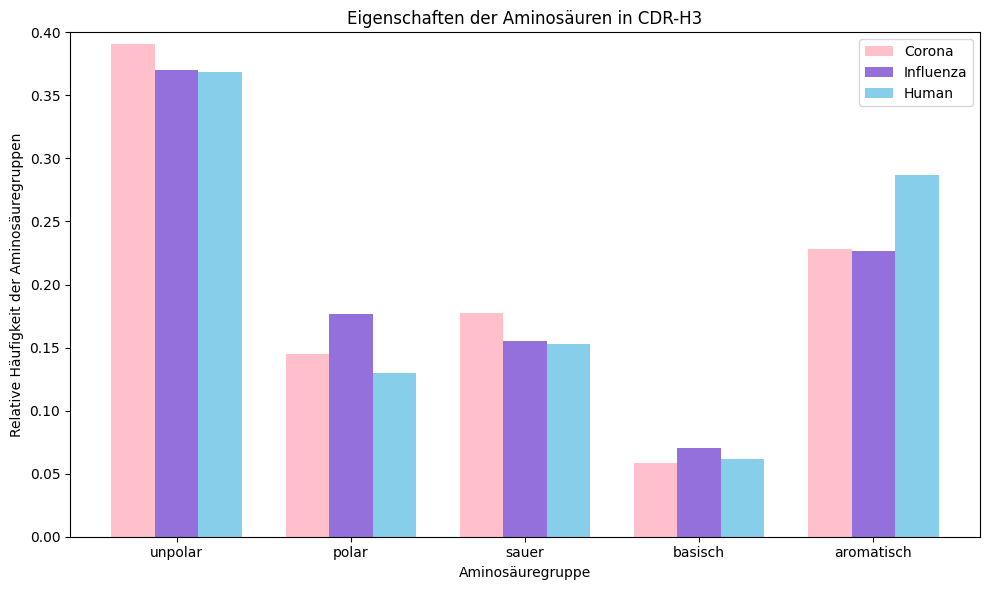

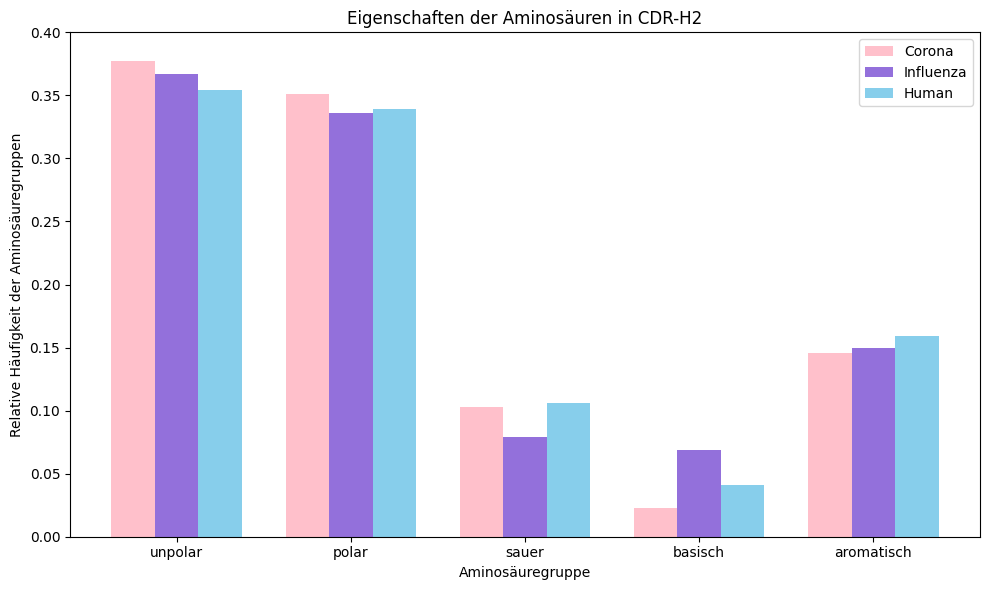

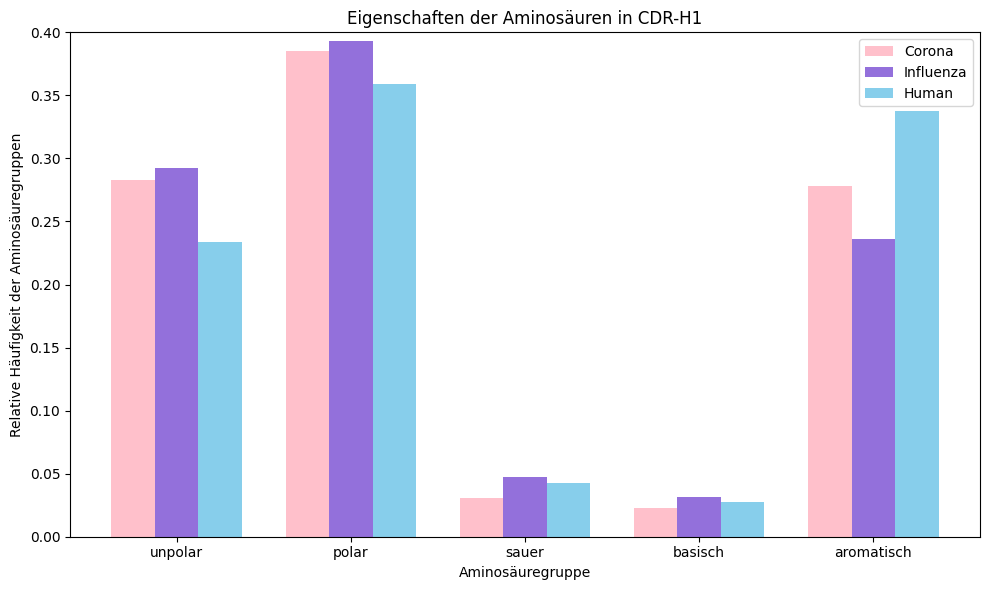

In [18]:
plot_property_groups(aac_sars_h3, aac_influenza_h3, aac_human_h3, region_label="CDR-H3")
plot_property_groups(aac_sars_h2, aac_influenza_h2, aac_human_h2, region_label="CDR-H2")
plot_property_groups(aac_sars_h1, aac_influenza_h1, aac_human_h1, region_label="CDR-H1")
